# Section 7 Pretrained Models for Transfer Learning

## 7.1 Tensorflow Dataset

In [1]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset

2023-01-20 06:51:42.426977: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-20 06:51:44.133404: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-20 06:51:44.169866: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-20 06:51:44.170272: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

{'train': <PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}

In [2]:
info

tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_path='/home/yu/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.tensorflow.org/example_images/flower_photos.tgz" }""",
)

In [3]:
print(info.splits)
dataset_size = info.splits["train"].num_examples
dataset_size

{'train': <SplitInfo num_examples=3670, num_shards=2>}


3670

In [4]:
class_names = info.features["label"].names
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [5]:
n_classes = info.features["label"].num_classes
n_classes

5

In [6]:
set_test, set_valid, set_train = tfds.load("tf_flowers", split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
                                           as_supervised=True)
set_train

<PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

********************************************
Data type:  uint8
Data shape:  (240, 240, 3)
Data value range:  0 255
dandelion


2023-01-20 06:51:45.971924: W tensorflow/core/kernels/data/cache_dataset_ops.cc:856] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


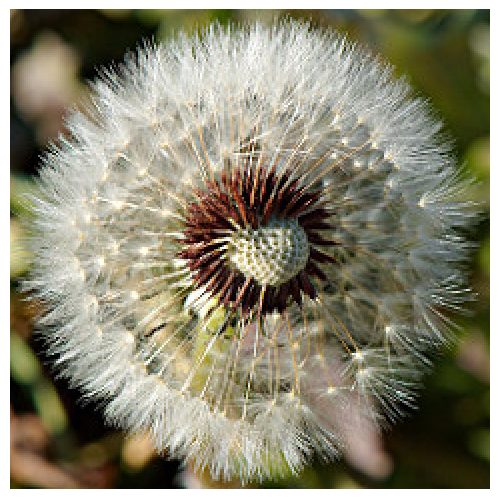

********************************************
Data type:  uint8
Data shape:  (375, 500, 3)
Data value range:  0 255
dandelion


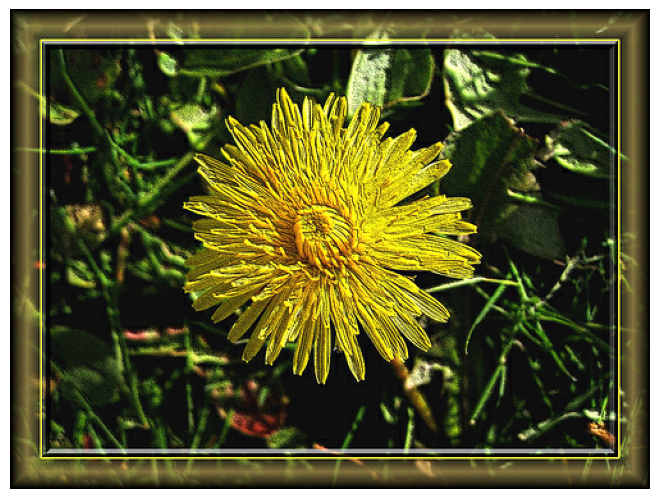

********************************************
Data type:  uint8
Data shape:  (334, 500, 3)
Data value range:  0 255
dandelion


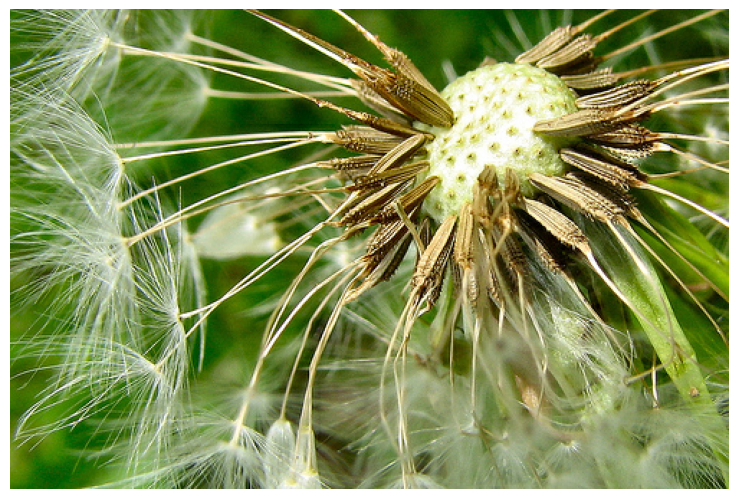

********************************************
Data type:  uint8
Data shape:  (240, 207, 3)
Data value range:  0 255
daisy


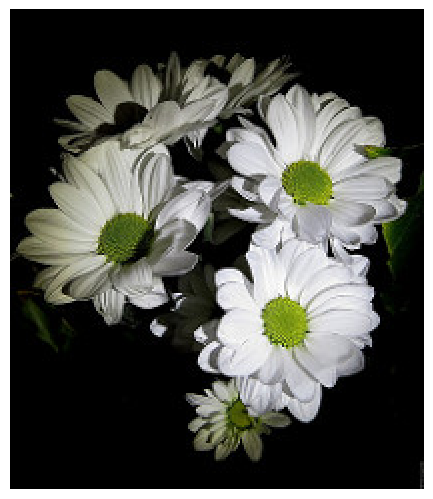

********************************************
Data type:  uint8
Data shape:  (265, 500, 3)
Data value range:  0 255
dandelion


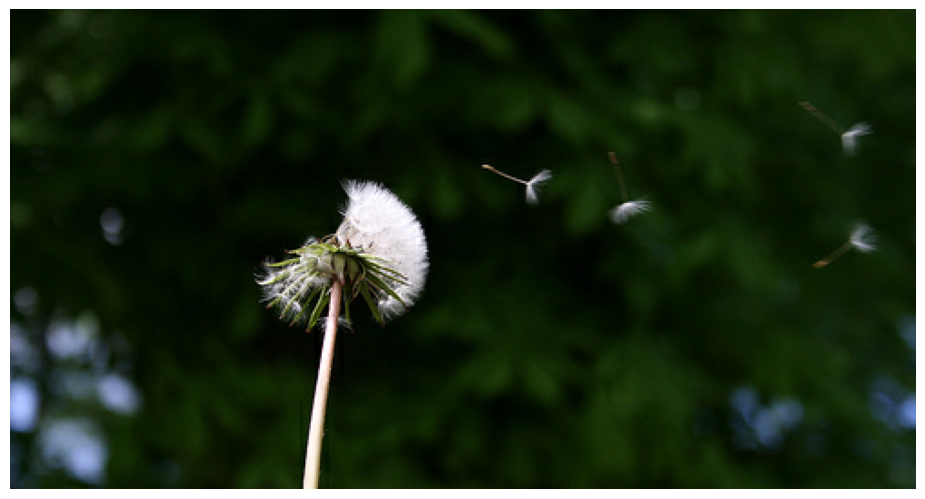

In [7]:
from data_science.util.print_images import print_images

sample_images, sample_labels = list(zip(*[instance for instance in list(set_train.take(5))]))
sample_images = [sample_image.numpy() for sample_image in sample_images]
sample_labels = [sample_label.numpy() for sample_label in sample_labels]
print_images(sample_images, titles=[class_names[sample_label] for sample_label in sample_labels])

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -1.0 1.0


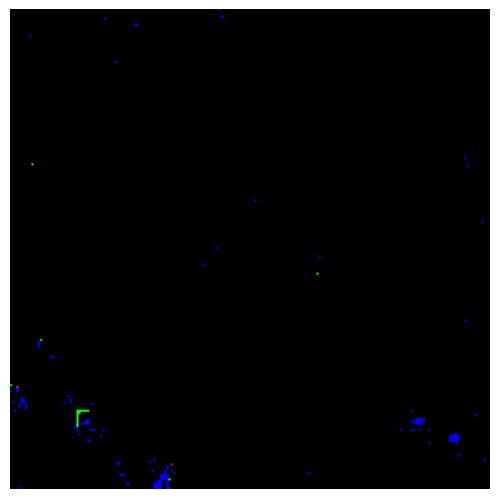

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -1.0 1.0


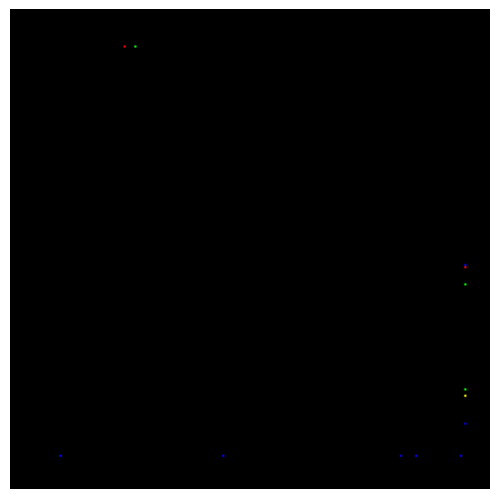

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -1.0 1.0


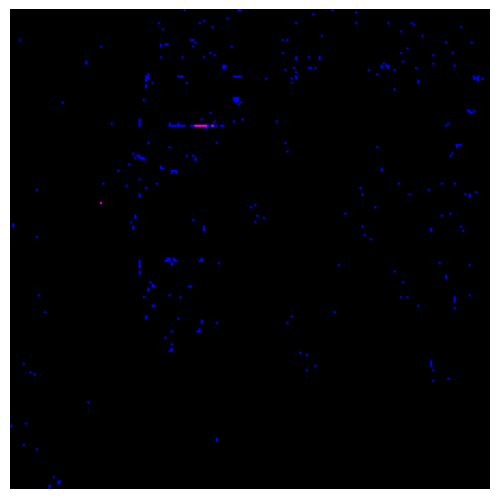

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -1.0 0.9949025


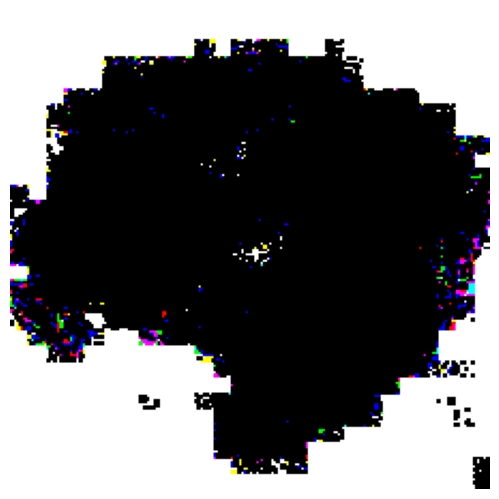

********************************************
Data type:  float32
Data shape:  (224, 224, 3)
Data value range:  -1.0 1.0


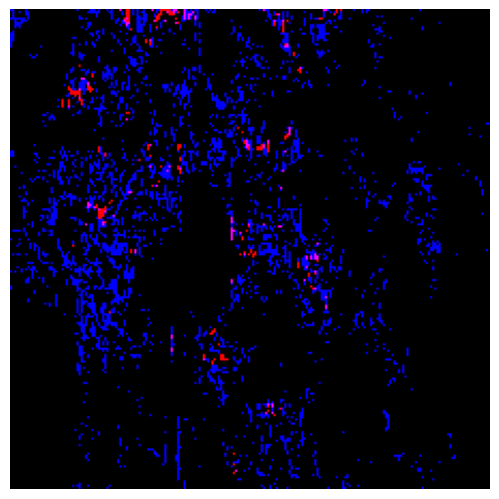

In [8]:
import tensorflow as tf
from typing import Tuple

def preprocess_image(image: tf.Tensor, label: int) -> Tuple[tf.Tensor, int]:
    image_resized = tf.image.resize(image, [224, 224])
    image_final = tf.keras.applications.xception.preprocess_input(image_resized)
    return image_final, label

images_prep = [preprocess_image(image, label)[0].numpy() for image, label in zip(sample_images, sample_labels)]
print_images(images_prep)

In [9]:
batch_size = 8  # 32 result in OOM
set_train = set_train.shuffle(1000)
set_train = set_train.map(preprocess_image).batch(batch_size).prefetch(1)
set_valid = set_valid.map(preprocess_image).batch(batch_size).prefetch(1)
set_test = set_test.map(preprocess_image).batch(batch_size).prefetch(1)

## 7.2 TensorFlow Pretrained Model

In [10]:
base_model = tf.keras.applications.xception.Xception(include_top=False, weights="imagenet")
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
out = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=out)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 block1_conv1 (Conv2D)          (None, None, None,   864         ['input_1[0][0]']                
                                32)                                                               
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, None, None,   128        ['block1_conv1[0][0]']           
 ation)                         32)                                                           

In [11]:
import time
from pathlib import Path

def get_run_logdir():
    run_id = time.strftime("run_%Y_%m_%d-%H-%M-%S")
    return Path() / run_id

cb_tensorboard = tf.keras.callbacks.TensorBoard(get_run_logdir())

%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

Launching TensorBoard...

In [12]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.2, momentum=0.9, decay=0.01)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model.fit(set_train, epochs=5, validation_data=set_valid, callbacks=[cb_tensorboard])

Epoch 1/5


2023-01-20 06:51:59.264140: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401
2023-01-20 06:51:59.906046: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-20 06:51:59.906933: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-20 06:51:59.906961: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2023-01-20 06:51:59.907735: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-20 06:51:59.907801: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2023-01-20 06:52:01.364657: W tensorflow/core/common_runtime/bf

344/344 [==============================] - ETA: 0s - loss: 1.5349 - accuracy: 0.2914

2023-01-20 06:57:05.363446: W tensorflow/core/common_runtime/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.35GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


344/344 [==============================] - 312s 870ms/step - loss: 1.5349 - accuracy: 0.2914 - val_loss: 1.4460 - val_accuracy: 0.2940
Epoch 2/5
344/344 [==============================] - 264s 768ms/step - loss: 1.3745 - accuracy: 0.3906 - val_loss: 1.3745 - val_accuracy: 0.3975
Epoch 3/5
344/344 [==============================] - 247s 719ms/step - loss: 1.3439 - accuracy: 0.4073 - val_loss: 1.3971 - val_accuracy: 0.4338
Epoch 4/5
344/344 [==============================] - 260s 756ms/step - loss: 1.3082 - accuracy: 0.4346 - val_loss: 1.3539 - val_accuracy: 0.4610
Epoch 5/5
344/344 [==============================] - 261s 758ms/step - loss: 1.2824 - accuracy: 0.4382 - val_loss: 1.2857 - val_accuracy: 0.4410


In [13]:
model.predict(set_test)

46/46 [==============================] - 6s 114ms/step


array([[1.2210857e-05, 2.2944460e-04, 7.0985150e-01, 1.2302493e-02,
        2.7760428e-01],
       [1.8521258e-01, 2.0058659e-01, 1.5288760e-01, 3.0223882e-01,
        1.5907447e-01],
       [2.7176288e-01, 2.3392080e-01, 1.0187829e-01, 2.8175694e-01,
        1.1068112e-01],
       ...,
       [4.9007478e-01, 2.6284856e-01, 3.0984120e-02, 1.7651695e-01,
        3.9575588e-02],
       [1.7997943e-01, 1.9620334e-01, 1.5755479e-01, 3.0321622e-01,
        1.6304623e-01],
       [4.3533275e-01, 2.6555258e-01, 4.2803403e-02, 2.0355269e-01,
        5.2758656e-02]], dtype=float32)

## 7.3 Classificaion and Localization

In [14]:
base_model = tf.keras.applications.xception.Xception(include_top=False, weights="imagenet")
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
out_cls = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
out_loc = tf.keras.layers.Dense(4)(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=[out_cls, out_loc])
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 block1_conv1 (Conv2D)          (None, None, None,   864         ['input_2[0][0]']                
                                32)                                                               
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, None, None,   128        ['block1_conv1[0][0]']           
 ation)                         32)                                                         

In [ ]:
optimizer = tf.keras.optimizers.SGD(lr=0.2, momentum=0.9, decay=0.01)
model.compile(loss=["sparse_categorical_crossentropy", "mse"], loss_weights=[0.8, 0.2], optimizer=optimizer, metrics=["accuracy"])
history = model.fit(set_train, epochs=5, validation_data=set_valid, callbacks=[cb_tensorboard])

Epoch 1/5


/home/yu/.local/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/gradient_descent.py:111: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


344/344 [==============================] - 243s 692ms/step - loss: 1.7182 - dense_1_loss: 1.6265 - dense_2_loss: 2.0853 - dense_1_accuracy: 0.2213 - dense_2_accuracy: 0.2031 - val_loss: 1.6920 - val_dense_1_loss: 1.6121 - val_dense_2_loss: 2.0115 - val_dense_1_accuracy: 0.2323 - val_dense_2_accuracy: 0.2377
Epoch 2/5
344/344 [==============================] - 213s 621ms/step - loss: 1.6876 - dense_1_loss: 1.6077 - dense_2_loss: 2.0069 - dense_1_accuracy: 0.2435 - dense_2_accuracy: 0.2402 - val_loss: 1.6869 - val_dense_1_loss: 1.6057 - val_dense_2_loss: 2.0119 - val_dense_1_accuracy: 0.2323 - val_dense_2_accuracy: 0.2377
Epoch 3/5
344/344 [==============================] - 205s 595ms/step - loss: 1.6847 - dense_1_loss: 1.6041 - dense_2_loss: 2.0074 - dense_1_accuracy: 0.2293 - dense_2_accuracy: 0.2402 - val_loss: 1.6862 - val_dense_1_loss: 1.6052 - val_dense_2_loss: 2.0101 - val_dense_1_accuracy: 0.2377 - val_dense_2_accuracy: 0.2377
Epoch 4/5
179/344 [==============>...............] - 